**Import liberaries**

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("feyzazkefe/trashnet")

print("Path to dataset files:", path)

Path to dataset files: /home/norah/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1


In [6]:
import os

dataset_dir = path + "/dataset-resized"   
for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)
    print(f"{cls}: {len(os.listdir(cls_path))} images")

glass: 501 images
metal: 410 images
cardboard: 403 images
paper: 594 images
plastic: 482 images
trash: 137 images


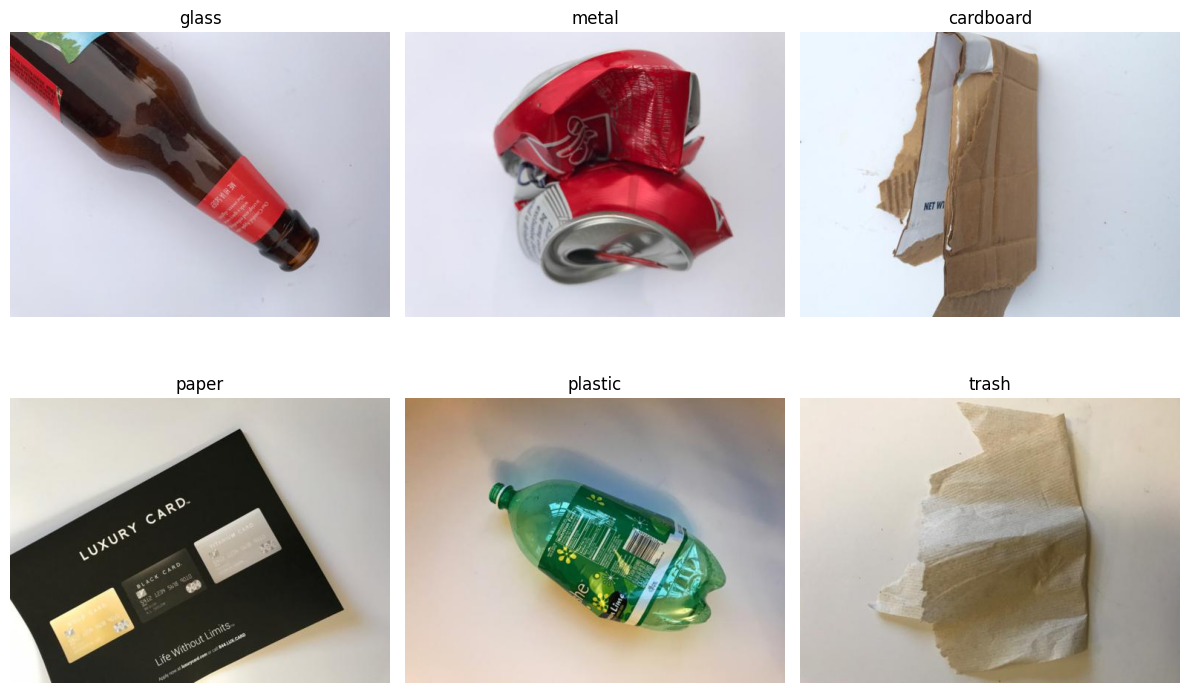

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = os.listdir(dataset_dir)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(dataset_dir, cls))[0]

    img_path = os.path.join(dataset_dir, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import cv2
import matplotlib.pyplot as plt

sample_img = img_path

img = cv2.imread(sample_img)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize
resized = cv2.resize(img,(224,224))

# Gaussian filter
blur = cv2.GaussianBlur(resized,(5,5),0)

# CLAHE
gray = cv2.cvtColor(blur,cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced = clahe.apply(gray)

# Edge detection
edges = cv2.Canny(enhanced,100,200)

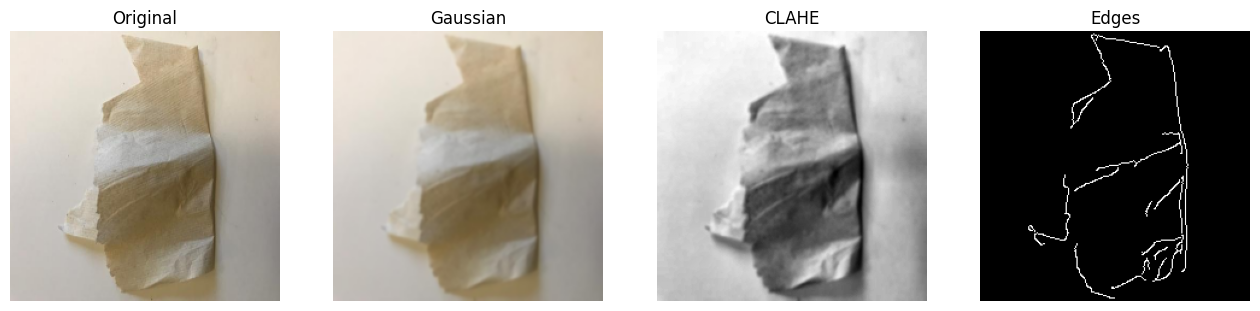

In [9]:
fig, ax = plt.subplots(1,4,figsize=(16,4))

ax[0].imshow(resized)
ax[0].set_title("Original")

ax[1].imshow(blur)
ax[1].set_title("Gaussian")

ax[2].imshow(enhanced,cmap='gray')
ax[2].set_title("CLAHE")

ax[3].imshow(edges,cmap='gray')
ax[3].set_title("Edges")

for a in ax:
    a.axis('off')

plt.show()

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [11]:
print(train_generator.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

model.summary()

2026-05-29 20:48:28.728473: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-29 20:48:28.733008: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 998ms/step - accuracy: 0.6611 - loss: 0.9243 - val_accuracy: 0.7356 - val_loss: 0.7455
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 950ms/step - accuracy: 0.8192 - loss: 0.5149 - val_accuracy: 0.6998 - val_loss: 0.8117
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8577 - loss: 0.4024 - val_accuracy: 0.7435 - val_loss: 0.6491
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 966ms/step - accuracy: 0.8681 - loss: 0.3459 - val_accuracy: 0.7495 - val_loss: 0.6784
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 923ms/step - accuracy: 0.8898 - loss: 0.2954 - val_accuracy: 0.7296 - val_loss: 0.7884
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9081 - loss: 0.2500 - val_accuracy: 0.7694 - val_loss: 0.6986
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 894ms/step - accuracy: 0.9269 - loss: 0.2033 - val_accuracy: 0.7416 - val_loss: 0.8015
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 997ms/step - accuracy: 0.9432 - loss: 0.1705 - val_accuracy: 